In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Problem 1.

In [2]:
# defining the function
lemda = 0.5
tf = 10
h = 0.5
N0 = 1000
def decay_rate(t,N,lemda = 0.5):
    return -lemda*N

In [3]:
# Euler method.
def euler(tf = 10, h = 0.5, t0 = 0, N0 = 1000):
    t = np.arange(t0,tf+0.1,h)
    N = np.zeros(len(t))
    t[0] = t0
    N[0] = N0 

    for i in range(len(t)-1):
        N[i+1] = N[i] + h*decay_rate(t[i],N[i])

    return t,N

In [4]:
# Runge-Kutte method (RK4). 
def rk4(tf = 10, h = 0.5, t0 = 0, N0 = 1000):
    
    t = np.arange(t0,tf+0.1,h)
    N = np.zeros(len(t))
    t[0] = t0
    N[0] = N0 

    for i in range(len(t)-1):
        k1 = decay_rate(t[i],N[i])
        k2 = decay_rate(t[i]+h/2,N[i]+k1*h/2)
        k3 = decay_rate(t[i]+h/2,N[i]+k2*h/2)
        k4 = decay_rate(t[i]+h,N[i]+k3*h)
        N[i+1] = N[i] + h/6*(k1+2*(k2+k3)+k4)


    return t,N

In [5]:
# Heun’s method (Improved Euler or RK2)
def heuns_rule(tf = 10, h = 0.5, t0 = 0, N0 = 1000):
    
    t = np.arange(t0,tf+0.1,h)
    N = np.zeros(len(t))
    t[0] = t0
    N[0] = N0 

    for i in range(len(t)-1):
        k1 = decay_rate(t[i],N[i])
        k2 = decay_rate(t[i]+h*0.5,N[i]+h*k1)
        N[i+1] = N[i] + 0.5*h*(k1 + k2)

    return t,N

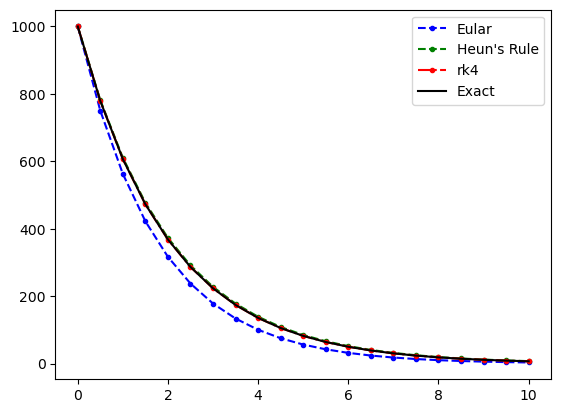

In [6]:
t,N = euler()
t1,N1 = heuns_rule()
t2,N2 = rk4()
plt.plot(t,N, marker = '.', color = 'b', linestyle = '--', label = 'Eular')
plt.plot(t1,N1, marker = '.', color = 'g', linestyle = '--', label = "Heun's Rule")
plt.plot(t2,N2, marker = '.', color = 'r', linestyle = '-.', label = "rk4")
plt.plot(t, N0*np.exp(-lemda*t), color = 'black',label = 'Exact', zorder = 100)
plt.legend()
plt.show()

In [85]:
print(t[-1])
print(N[-1])
print(N1[-1])
print(N2[-1])
print(N0*np.exp(-lemda*10))

10.0
3.1712119389339932
7.174648137343063
6.739298640071323
6.737946999085467


In [65]:
# error analysis
error1 = abs(N[-1]-N0*np.exp(-lemda*10))
error2 = abs(N1[-1]-N0*np.exp(-lemda*10))
error3 = abs(N2[-1]-N0*np.exp(-lemda*10))
print(
    f'Error in Euler method = {error1}\n'
    f'Error in Heuns method = {error2}\n'
    f'Error in RK4 method = {error3}\n'
    f'The error in RK4 method is less any other methods therefore this method is one of the most widely used numerical methods in computational physics.'
)

Error in Euler method = 3.5667350601514736
Error in Heuns method = 0.4367011382575958
Error in RK4 method = 0.0013516409858560507
The error in RK4 method is less any other methods therefore this method is one of the most widely used numerical methods in computational physics.


# Problem 2.

In [16]:
# Euler method

# constants
G = 1

# Masses
m1 = 1.0
m2 = 0.5

# positions
x1 = 0.0
y1 = 0.0
x2 = 1.0
y2 = 0.0

# velocities
v1x = 0.0
v1y = 0.0
v2x = 0.0
v2y = 0.6

dt = 0.01
steps = 10000

# trajectories
x1_traj = []
y1_traj = []
x2_traj = []
y2_traj = []
xcom_traj = []
ycom_traj = []


for i in range(steps):

    # distances
    dx = x2 - x1
    dy = y2 - y1
    r = (dx**2 + dy**2)**0.5
    r3 = r**3


    # forces
    Fx = G*m1*m2*dx/r3
    Fy = G*m1*m2*dy/r3


    # acceleration
    a1x = Fx/m1
    a1y = Fy/m1
    a2x = -Fx/m2
    a2y = -Fy/m2

    # velocites
    v1x = a1x*dt + v1x
    v1y = a1y*dt + v1y
    v2x = a2x*dt + v2x
    v2y = a2y*dt + v2y

    # position
    x1 = v1x*dt + x1
    y1 = v1y*dt + y1
    x2 = v2x*dt + x2
    y2 = v2y*dt + y2


    # center of mass
    xcom = (m1*x1 + m2*x2)/(m1 + m2)
    ycom = (m1*y1 + m2*y2)/(m1 + m2)


    # append trajectories
    x1_traj.append(x1)
    y1_traj.append(y1)
    x2_traj.append(x2)
    y2_traj.append(y2)
    xcom_traj.append(xcom)
    ycom_traj.append(ycom)

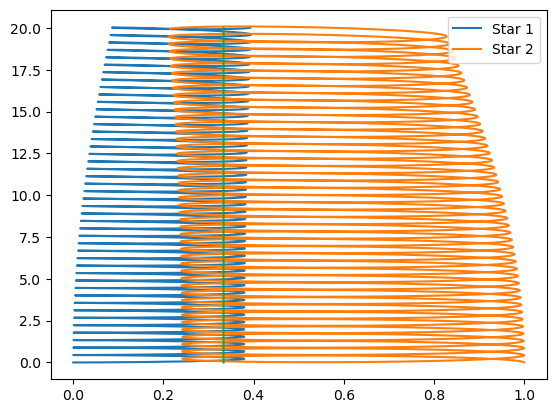

In [17]:
plt.plot(x1_traj,y1_traj, label = 'Star 1')
plt.plot(x2_traj,y2_traj, label = 'Star 2')
plt.plot(xcom_traj,ycom_traj)
plt.legend()

In [18]:
x1com = np.array(x1_traj) - np.array(xcom_traj)
y1com = np.array(y1_traj) - np.array(ycom_traj)
x2com = np.array(x2_traj) - np.array(xcom_traj)
y2com = np.array(y2_traj) - np.array(ycom_traj)

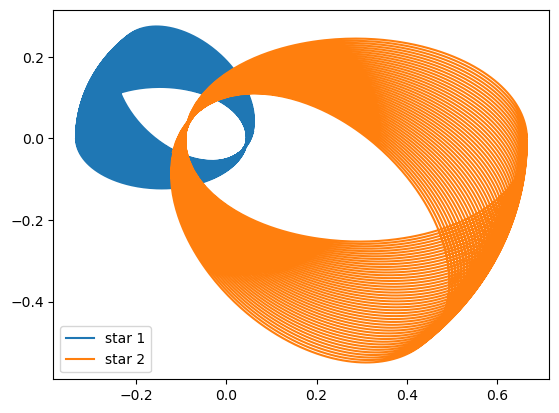

In [19]:
plt.plot(x1com, y1com, label = 'star 1')
plt.plot(x2com, y2com, label = 'star 2')
plt.legend()

In [59]:
# constants
G = 1

# Masses
m1 = 1
m2 = 0.9220026651778074
m3 = 0.8398987448988406

state = [0.1, 1.0, 1.0, 0.8, 0.9, 0.7000000000000001, 0.0, 0.9, 0.1, 0.6000000000000001, 1.0, 0.0]# time and steps
t = 0
steps = 155000
dt = 9.5e-06

# trajectories
x1_traj, y1_traj = [], []
x2_traj, y2_traj = [], []
x3_traj, y3_traj = [], []
xcom_traj, ycom_traj = [], []
E, time = [], []

def derivatives(s):
    x1, y1, x2, y2, x3, y3, v1x, v1y, v2x, v2y, v3x, v3y = s

    dx12 = x2 - x1
    dx23 = x3 - x2
    dx31 = x1 - x3
    dy12 = y2 - y1
    dy23 = y3 - y2
    dy31 = y1 - y3
    
    r12 = (dx12**2 + dy12**2)**0.5
    r23 = (dx23**2 + dy23**2)**0.5
    r31 = (dx31**2 + dy31**2)**0.5
    

    # forces
    Fx1 = G*m1*m2*dx12/(r12**3) - G*m3*m1*dx31/(r31**3)
    Fy1 = G*m1*m2*dy12/(r12**3) - G*m3*m1*dy31/(r31**3)
    Fx2 = - G*m1*m2*dx12/(r12**3) + G*m2*m3*dx23/(r23**3)
    Fy2 = - G*m1*m2*dy12/(r12**3) + G*m2*m3*dy23/(r23**3)
    Fx3 = G*m3*m1*dx31/(r31**3) - G*m2*m3*dx23/(r23**3)
    Fy3 = G*m3*m1*dy31/(r31**3) - G*m2*m3*dy23/(r23**3)
    

    # acceleration
    a1x = Fx1/m1
    a1y = Fy1/m1
    a2x = Fx2/m2
    a2y = Fy2/m2
    a3x = Fx3/m3
    a3y = Fy3/m3

    return [v1x, v1y, v2x, v2y, v3x, v3y, a1x, a1y, a2x, a2y, a3x, a3y]


for i in range(steps):

    # RK4 steps
    k1 = derivatives(state)

    k2 = derivatives([s + dt/2 * k for s, k in zip(state, k1)])

    k3 = derivatives([s + dt/2 * k for s, k in zip(state, k2)])

    k4 = derivatives([s + dt * k for s, k in zip(state, k3)])

    # update state
    state = [
        s + dt/6 * (k1_i + 2*k2_i + 2*k3_i + k4_i)
        for s, k1_i, k2_i, k3_i, k4_i in zip(state, k1, k2, k3, k4)
    ]

    x1, y1, x2, y2, x3, y3, v1x, v1y, v2x, v2y, v3x, v3y = state

    


    # time and energy
    
    dx12 = x2 - x1
    dx23 = x3 - x2
    dx31 = x1 - x3
    dy12 = y2 - y1
    dy23 = y3 - y2
    dy31 = y1 - y3
    r12 = (dx12**2 + dy12**2)**0.5
    r23 = (dx23**2 + dy23**2)**0.5
    r31 = (dx31**2 + dy31**2)**0.5
    # velocity squared
    v1_sqre = v1x**2 + v1y**2
    v2_sqre = v2x**2 + v2y**2
    v3_sqre = v3x**2 + v3y**2
    
    t += dt
    energy = -G*(m1*m2/r12 + m1*m3/r31 + m2*m3/r23) + 0.5*(m1*v1_sqre + m2*v2_sqre + m3*v3_sqre)


    # center of mass
    xcom = (m1*x1 + m2*x2 + m3*x3)/(m1 + m2 + m3)
    ycom = (m1*y1 + m2*y2 + m3*y3)/(m1 + m2 + m3)

    


    # append trajectories
    x1_traj.append(x1)
    y1_traj.append(y1)
    x2_traj.append(x2)
    y2_traj.append(y2)
    x3_traj.append(x3)
    y3_traj.append(y3)
    xcom_traj.append(xcom)
    ycom_traj.append(ycom)
    # total mechanical energy
    E.append(energy)
    time.append(t)

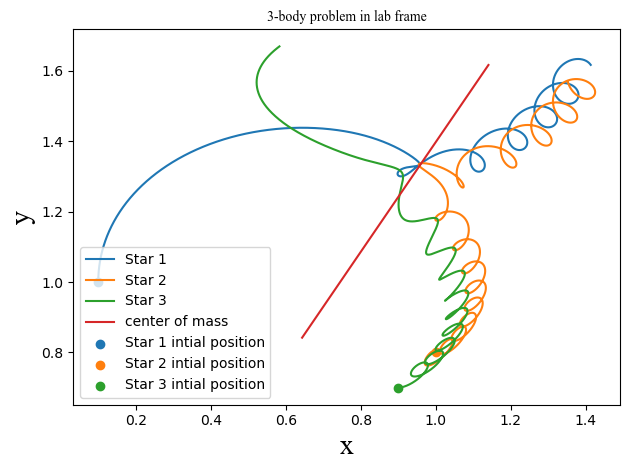

In [60]:
plt.plot(x1_traj,y1_traj, label = 'Star 1')
plt.plot(x2_traj,y2_traj, label = 'Star 2')
plt.plot(x3_traj,y3_traj, label = 'Star 3')
plt.plot(xcom_traj,ycom_traj, label = 'center of mass')
plt.scatter(x = x1_traj[0] ,y = y1_traj[0], label = 'Star 1 intial position')
plt.scatter(x = x2_traj[0] ,y = y2_traj[0], label = 'Star 2 intial position')
plt.scatter(x = x3_traj[0] ,y = y3_traj[0], label = 'Star 3 intial position')
plt.title('3-body problem in lab frame', font = 'times new roman')
plt.xlabel('x',fontsize = 20, font = 'times new roman')
plt.ylabel('y',fontsize = 20, font = 'times new roman')
plt.tight_layout()
plt.legend()
#plt.savefig('3-body_problem_in_lab_frame.png', dpi = 1500)
plt.show()

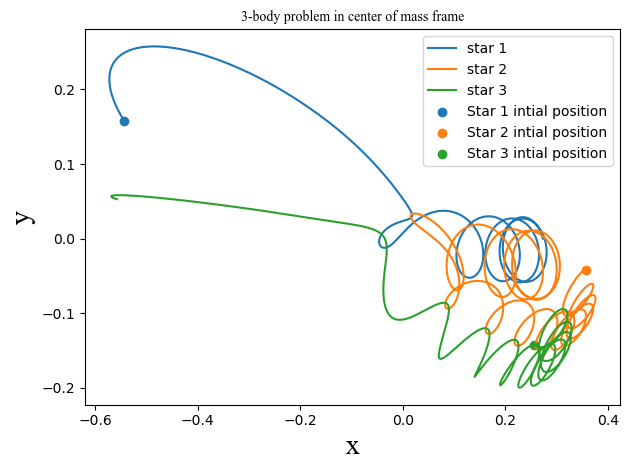

In [61]:
x1com = np.array(x1_traj) - np.array(xcom_traj)
y1com = np.array(y1_traj) - np.array(ycom_traj)
x2com = np.array(x2_traj) - np.array(xcom_traj)
y2com = np.array(y2_traj) - np.array(ycom_traj)
x3com = np.array(x3_traj) - np.array(xcom_traj)
y3com = np.array(y3_traj) - np.array(ycom_traj)
plt.plot(x1com, y1com, label = 'star 1')
plt.plot(x2com, y2com, label = 'star 2')
plt.plot(x3com, y3com, label = 'star 3')
plt.scatter(x = x1com[0] ,y = y1com[0], label = 'Star 1 intial position')
plt.scatter(x = x2com[0] ,y = y2com[0], label = 'Star 2 intial position')
plt.scatter(x = x3com[0] ,y = y3com[0], label = 'Star 3 intial position')
plt.title('3-body problem in center of mass frame',font = 'times new roman')
plt.xlabel('x',fontsize = 20, font = 'times new roman')
plt.ylabel('y',fontsize = 20, font = 'times new roman')
plt.tight_layout()
plt.legend()
#plt.savefig('3-body_problem_in_center_of_mass_frame.png', dpi = 1500)


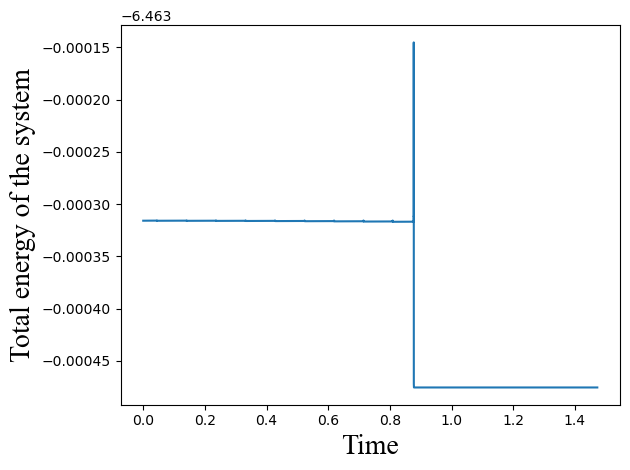

In [62]:
plt.plot(time, E)
plt.xlabel('Time',fontsize = 20, font = 'times new roman')
plt.ylabel('Total energy of the system',fontsize = 20, font = 'times new roman')
plt.tight_layout()
#plt.savefig('energy_time_graph.png', dpi = 1500)

# problem 3.

In [14]:
# RK4 method

# constants
G = 1

# Masses
m1 = 1.0
m2 = 0.5

# positions
x1 = 0.0
y1 = 0.0
x2 = 1.0
y2 = 0.0

# velocities
v1x = 0.0
v1y = 0.0
v2x = 0.0
v2y = 0.6

dt = 0.01
steps = 10000

# trajectories
x1_traj = [x1]
y1_traj = [y1]
x2_traj = [x2]
y2_traj = [y2]
xcom_traj = [(m1*x1 + m2*x2)/(m1 + m2)]
ycom_traj = [(m1*y1 + m2*y2)/(m1 + m2)]


for i in range(steps):
    
    # velocities
    v1x_1 = v1x
    v1y_1 = v1y
    v2x_1 = v2x
    v2y_1 = v2y
    
    # distances
    dx_1 = x2 - x1
    dy_1 = y2 - y1
    r_1 = (dx_1**2 + dy_1**2)**0.5
    r3_1 = r_1**3
    
    
    # forces
    Fx_1 = G*m1*m2*dx_1/r3_1
    Fy_1 = G*m1*m2*dy_1/r3_1
    
    
    # acceleration
    a1x_1 = Fx_1/m1
    a1y_1 = Fy_1/m1
    a2x_1 = -Fx_1/m2
    a2y_1 = -Fy_1/m2

    
    



    
    
    # position
    x1_2 = v1x*dt/2 + x1
    y1_2 = v1y*dt/2 + y1
    x2_2 = v2x*dt/2 + x2
    y2_2 = v2y*dt/2 + y2

    # velocities
    v1x_2 = v1x + a1x_1*dt/2
    v1y_2 = v1y + a1y_1*dt/2
    v2x_2 = v2x + a2x_1*dt/2
    v2y_2 = v2y + a2y_1*dt/2

    # distances
    dx_2 = x2_2 - x1_2
    dy_2 = y2_2 - y1_2
    r_2 = (dx_2**2 + dy_2**2)**0.5
    r3_2 = r_2**3


    # forces
    Fx_2 = G*m1*m2*dx_2/r3_2
    Fy_2 = G*m1*m2*dy_2/r3_2


    # acceleration
    a1x_2 = Fx_2/m1
    a1y_2 = Fy_2/m1
    a2x_2 = -Fx_2/m2
    a2y_2 = -Fy_2/m2



    
    
    # position
    x1_3 = v1x_2*dt/2 + x1
    y1_3 = v1y_2*dt/2 + y1
    x2_3 = v2x_2*dt/2 + x2
    y2_3 = v2y_2*dt/2 + y2

    # velocities
    v1x_3 = v1x + a1x_2*dt/2
    v1y_3 = v1y + a1y_2*dt/2
    v2x_3 = v2x + a2x_2*dt/2
    v2y_3 = v2y + a2y_2*dt/2

    # distances
    dx_3 = x2_3 - x1_3
    dy_3 = y2_3 - y1_3
    r_3 = (dx_3**2 + dy_3**2)**0.5
    r3_3 = r_3**3

    # forces
    Fx_3 = G*m1*m2*dx_3/r3_3
    Fy_3 = G*m1*m2*dy_3/r3_3


    # acceleration
    a1x_3 = Fx_3/m1
    a1y_3 = Fy_3/m1
    a2x_3 = -Fx_3/m2
    a2y_3 = -Fy_3/m2




    
    # position
    x1_4 = v1x_3*dt + x1
    y1_4 = v1y_3*dt + y1
    x2_4 = v2x_3*dt + x2
    y2_4 = v2y_3*dt + y2

    # velocities
    v1x_4 = v1x + a1x_3*dt
    v1y_4 = v1y + a1y_3*dt
    v2x_4 = v2x + a2x_3*dt
    v2y_4 = v2y + a2y_3*dt

    # distances
    dx_4 = x2_4 - x1_4
    dy_4 = y2_4 - y1_4
    r_4 = (dx_4**2 + dy_4**2)**0.5
    r3_4 = r_4**3

    # forces
    Fx_4 = G*m1*m2*dx_4/r3_4
    Fy_4 = G*m1*m2*dy_4/r3_4


    # acceleration
    a1x_4 = Fx_4/m1
    a1y_4 = Fy_4/m1
    a2x_4 = -Fx_4/m2
    a2y_4 = -Fy_4/m2
    
    

    # velocites
    v1x = dt/6*(a1x_1 + a1x_4 + 2*(a1x_2 + a1x_3)) + v1x
    v1y = dt/6*(a1y_1 + a1y_4 + 2*(a1y_2 + a1y_3)) + v1y
    v2x = dt/6*(a2x_1 + a2x_4 + 2*(a2x_2 + a2x_3)) + v2x
    v2y = dt/6*(a2y_1 + a2y_4 + 2*(a2y_2 + a2y_3)) + v2y

    # position
    x1 = dt/6*(v1x_1 + v1x_4 + 2*(v1x_2 + v1x_3)) + x1
    y1 = dt/6*(v1y_1 + v1y_4 + 2*(v1y_2 + v1y_3)) + y1
    x2 = dt/6*(v2x_1 + v2x_4 + 2*(v2x_2 + v2x_3)) + x2
    y2 = dt/6*(v2y_1 + v2y_4 + 2*(v2y_2 + v2y_3)) + y2


    # center of mass
    xcom = (m1*x1 + m2*x2)/(m1 + m2)
    ycom = (m1*y1 + m2*y2)/(m1 + m2)
    
    
    # append trajectories
    x1_traj.append(x1)
    y1_traj.append(y1)
    x2_traj.append(x2)
    y2_traj.append(y2)
    xcom_traj.append(xcom)
    ycom_traj.append(ycom)



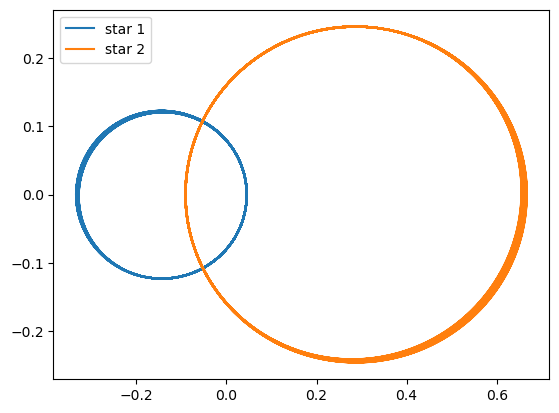

In [17]:
x1com = np.array(x1_traj) - np.array(xcom_traj)
y1com = np.array(y1_traj) - np.array(ycom_traj)
x2com = np.array(x2_traj) - np.array(xcom_traj)
y2com = np.array(y2_traj) - np.array(ycom_traj)
plt.plot(x1com, y1com, label = 'star 1')
plt.plot(x2com, y2com, label = 'star 2')

plt.legend()

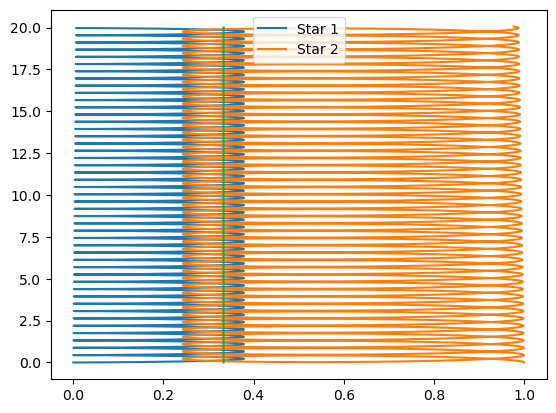

In [15]:
plt.plot(x1_traj,y1_traj, label = 'Star 1')
plt.plot(x2_traj,y2_traj, label = 'Star 2')
plt.plot(xcom_traj,ycom_traj)
plt.legend()

In [ ]:
# Intial condition
# constants
G = 1

# masses
m1 = 1
m2 = np.random.random()
m3 = np.random.random()

# initial position
x1 = 0.1*np.random.randint(0,11)
y1 = 0.1*np.random.randint(0,11)
x2 = 0.1*np.random.randint(0,11)
y2 = 0.1*np.random.randint(0,11)
x3 = 0.1*np.random.randint(0,11)
y3 = 0.1*np.random.randint(0,11)

# intiial velocities
v1x = 0.1*np.random.randint(0,11)
v1y = 0.1*np.random.randint(0,11)
v2x = 0.1*np.random.randint(0,11)
v2y = 0.1*np.random.randint(0,11)
v3x = 0.1*np.random.randint(0,11)
v3y = 0.1*np.random.randint(0,11)


# time and steps
t = 0
dt = 0.00000095
steps = 14500000


# trajectories
x1_traj = []
y1_traj = []
x2_traj = []
y2_traj = []
x3_traj = []
y3_traj = []
xcom_traj = []
ycom_traj = []
E = []
time = []


for i in range(steps):

    # distances
    dx12 = x2 - x1
    dx23 = x3 - x2
    dx31 = x1 - x3
    dy12 = y2 - y1
    dy23 = y3 - y2
    dy31 = y1 - y3
    r12 = (dx12**2 + dy12**2)**0.5
    r23 = (dx23**2 + dy23**2)**0.5
    r31 = (dx31**2 + dy31**2)**0.5
     

    # forces
    Fx1 = G*m1*m2*dx12/(r12**3) - G*m3*m1*dx31/(r31**3)
    Fy1 = G*m1*m2*dy12/(r12**3) - G*m3*m1*dy31/(r31**3)
    Fx2 = - G*m1*m2*dx12/(r12**3) + G*m2*m3*dx23/(r23**3)
    Fy2 = - G*m1*m2*dy12/(r12**3) + G*m2*m3*dy23/(r23**3)
    Fx3 = G*m3*m1*dx31/(r31**3) - G*m2*m3*dx23/(r23**3)
    Fy3 = G*m3*m1*dy31/(r31**3) - G*m2*m3*dy23/(r23**3)
    

    # acceleration
    a1x = Fx1/m1
    a1y = Fy1/m1
    a2x = Fx2/m2
    a2y = Fy2/m2
    a3x = Fx3/m3
    a3y = Fy3/m3

    # velocity squared
    v1_sqre = v1x**2 + v1y**2
    v2_sqre = v2x**2 + v2y**2
    v3_sqre = v3x**2 + v3y**2

    # velocites
    
    v1x += a1x*dt
    v1y += a1y*dt
    v2x += a2x*dt
    v2y += a2y*dt
    v3x += a3x*dt
    v3y += a3y*dt

    # position
    x1 = v1x*dt + x1
    y1 = v1y*dt + y1
    x2 = v2x*dt + x2
    y2 = v2y*dt + y2
    x3 = v3x*dt + x3
    y3 = v3y*dt + y3


    # time and energy
    
    t += dt
    energy = -G*(m1*m2/r12 + m1*m3/r31 + m2*m3/r23) + 0.5*(m1*v1_sqre + m2*v2_sqre + m3*v3_sqre)


    # center of mass
    xcom = (m1*x1 + m2*x2 + m3*x3)/(m1 + m2 + m3)
    ycom = (m1*y1 + m2*y2 + m3*y3)/(m1 + m2 + m3)

    


    # append trajectories
    x1_traj.append(x1)
    y1_traj.append(y1)
    x2_traj.append(x2)
    y2_traj.append(y2)
    x3_traj.append(x3)
    y3_traj.append(y3)
    xcom_traj.append(xcom)
    ycom_traj.append(ycom)
    # total mechanical energy
    E.append(energy)
    time.append(t)